# Importing libraries and data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from the adjacent 'Data' directory
df = pd.read_csv('../Data/Sleep_health_and_lifestyle_dataset.csv')

print('Fist five rows')
df.head()


Fist five rows


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# Observations

In [2]:
#Check the dataset's data types, the number of records, column names and missing values
print('info')
df.info()

#Check summary statistics
print("\ndescribe")
df.describe()

info
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB

describe


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


## Hypotheses

1. Stress directly decreases the sleep quality by making it harder to fall asleep, due to high heart rate and anxiety<br>
2. Stress degrades sleep quality (the sleep becomes superficial), while  the sleep quantity may remain unchanged or even increase, because the body tries to compensate for fatigue by staying in bed longer <br>


### Initial observations
To investigate our hypotheses, we grouped the dataset by `Stress Level` and calculated the mean values for all numberic fields. <br>
This allows us to observe general trends and see how changes in stress correspond to sleep metrics and demographics. <br>

In [39]:
agr_data_by_stress_level = df.groupby(by='Stress Level').mean(numeric_only=True)
agr_data_by_stress_level = agr_data_by_stress_level.drop(columns='Person ID')
agr_data_by_stress_level

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Heart Rate,Daily Steps
Stress Level,,,,,,
3,54.169014,8.226761,8.971831,54.718310,67.098592,6132.394366
4,39.900000,7.030000,7.671429,55.785714,66.828571,6422.857143
5,40.313433,7.483582,7.895522,74.253731,70.074627,7616.417910
6,33.065217,7.454348,7.000000,67.152174,70.717391,7363.043478
7,42.680000,6.468000,6.000000,43.840000,73.300000,5662.000000
8,39.742857,6.050000,5.857143,58.342857,74.100000,7605.714286


#### Key observations from the table:
- **Sleep duration trend:** As stress increases, there is a clear downward trend in sleep hours. The most significant drop is between stress levels 3 and 4.
- **The quality vs. quantity paradox:** Between stress levels 5 and 6, the average sleep duration remains almost identical (~7.45 hours), yet the subjective `Quality of Sleep` drops from 7.89 to 7.00. This provides early, indirect support for our second hypothesis.
- **Age and stress:** It is worth noting, the least stressed group (level 3) has the highest average age (~54 years), while the group with the lowest average age (~33 years) is found at stress level 6.

Text(0, 0.5, 'Average Quality of Sleep (4-9)')

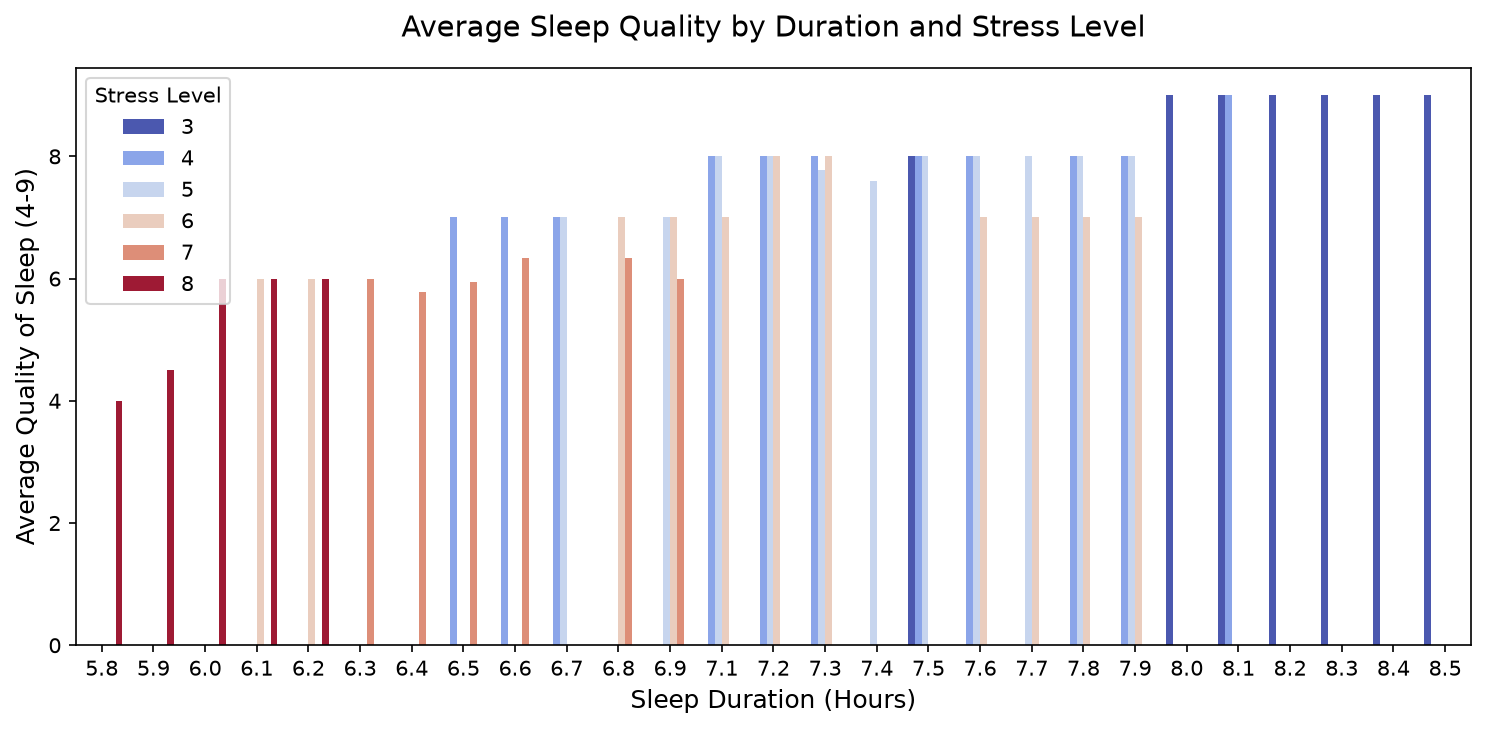

In [5]:
plt.figure(figsize=(12, 5), dpi=150)
sns.barplot(data = df, x='Sleep Duration', y ='Quality of Sleep', hue = 'Stress Level', palette='coolwarm', estimator=np.mean, errorbar=None)

plt.title('Average Sleep Quality by Duration and Stress Level', fontsize=14, pad=15)
plt.xlabel('Sleep Duration (Hours)', fontsize=12)
plt.ylabel('Average Quality of Sleep (4-9)', fontsize=12)

#### Key observations from the barplot:
While the aggregated table showed general trends, this bar chart reveals the distribution of the data and provides us with new observations: <br>

- **The volatility of stress level 6:** The chart highlights that people who estimated their stress level at '6' have a sleep duration from just over 6 hours (6.1) to almost 8 hours (7.9). This might mean that, regardless of how much extra time they spend in bed, their subjective `Quality of Sleep` never exceeds 8. This strongly strengthens **Hypothesis #2** (the sleep remains superficial and fails to recover efficiency).

- **The critical threshold (sleep < 6h):** Interestingly, individuals who sleep less than 6 hours exclusively estimated their stress level at '8', which is the maximum value in this dataset.

- **Data limitation note:** It is important to highlight a dataset limitation. The exact metrics and boundaries of the `Stress Level` scale are not fully documented (we only observe values from 3 to 8). The same situation applies to `Quality of Sleep`, where we only observe values between 4 and 9.


### Investigation of the correlation between `Stress Level` and `Heart Rate` (Hypothesis #1) 
To investigate our first hypothesis we'll take the following steps: <br>
1. Check for a correlation between `Stress Level` and `Heart Rate`
2. Check for a correlation between `Heart Rate` and both `Sleep Duration` and `Quality of Sleep`
3. Check for a correlation between `Stress Level` and `Sleep Disorder`

This will help us understand whether there is a physiological mechanism behind stress and see if a high heart rate impacts sleep quality and duration.

In [16]:
df[['Sleep Duration', 'Stress Level','Quality of Sleep','Heart Rate','Physical Activity Level','Daily Steps','Age']].corr()

,Sleep Duration,Stress Level,Quality of Sleep,Heart Rate,Physical Activity Level,Daily Steps,Age
Sleep Duration,1.000000,-0.811023,0.883213,-0.516455,0.212360,-0.039533,0.344709
Stress Level,-0.811023,1.000000,-0.898752,0.670026,-0.034134,0.186829,-0.422344
Quality of Sleep,0.883213,-0.898752,1.000000,-0.659865,0.192896,0.016791,0.473734
Heart Rate,-0.516455,0.670026,-0.659865,1.000000,0.136971,-0.030309,-0.225606
Physical Activity Level,0.212360,-0.034134,0.192896,0.136971,1.000000,0.772723,0.178993
Daily Steps,-0.039533,0.186829,0.016791,-0.030309,0.772723,1.000000,0.057973
Age,0.344709,-0.422344,0.473734,-0.225606,0.178993,0.057973,1.000000


#### Key observations from the table:
- **Correlation between stress level and heart rate:** We see the positive correlation coefficient between `Stress Level` and `Heart Rate` equals 0.67. It quantitatively supports the idea that a person's physiological state is highly related to their psychological state. 
- **A notable side insight:** Surprisingly, `Physical Activity Level` and `Stress Level` barely correlate (standing at just -0.03).
- **Age and stress:** Meanwhile, `Age` and `Stress Level` have a negative correlation (-0.42) that means older people experience less stress than younger ones in these data.

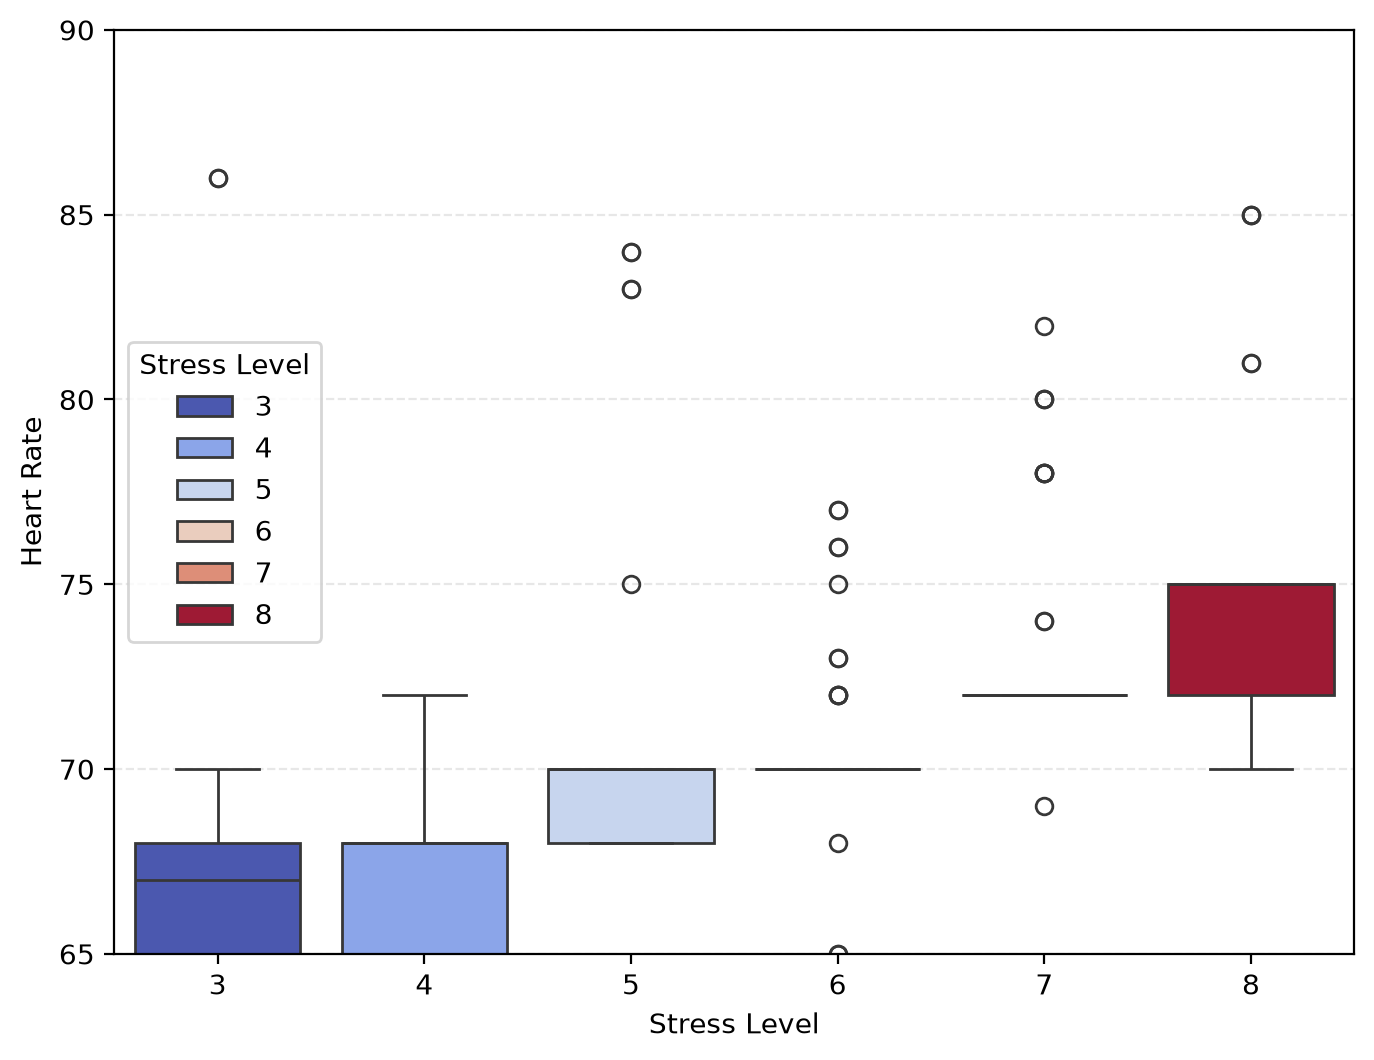

In [25]:
plt.figure(figsize=(8,6), dpi=200)
sns.boxplot(data=df, x='Stress Level', y = 'Heart Rate', hue = 'Stress Level', palette = 'coolwarm')
plt.ylim(65,90)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

#### Key observations from the boxplot:
- **Plot paradox:** The heart rate data in this dataset seems to be rounded because we observe groups of people clusterd around values like 60/70/75 beats per minute. 
- **This boxplot:** There is low variability of data, so we see the median merges with the box borders on several stress level. 
- **Next step:** To smooth this rounding effect and see at least agregation trend we decided to use a barplot that shows average heart rate.

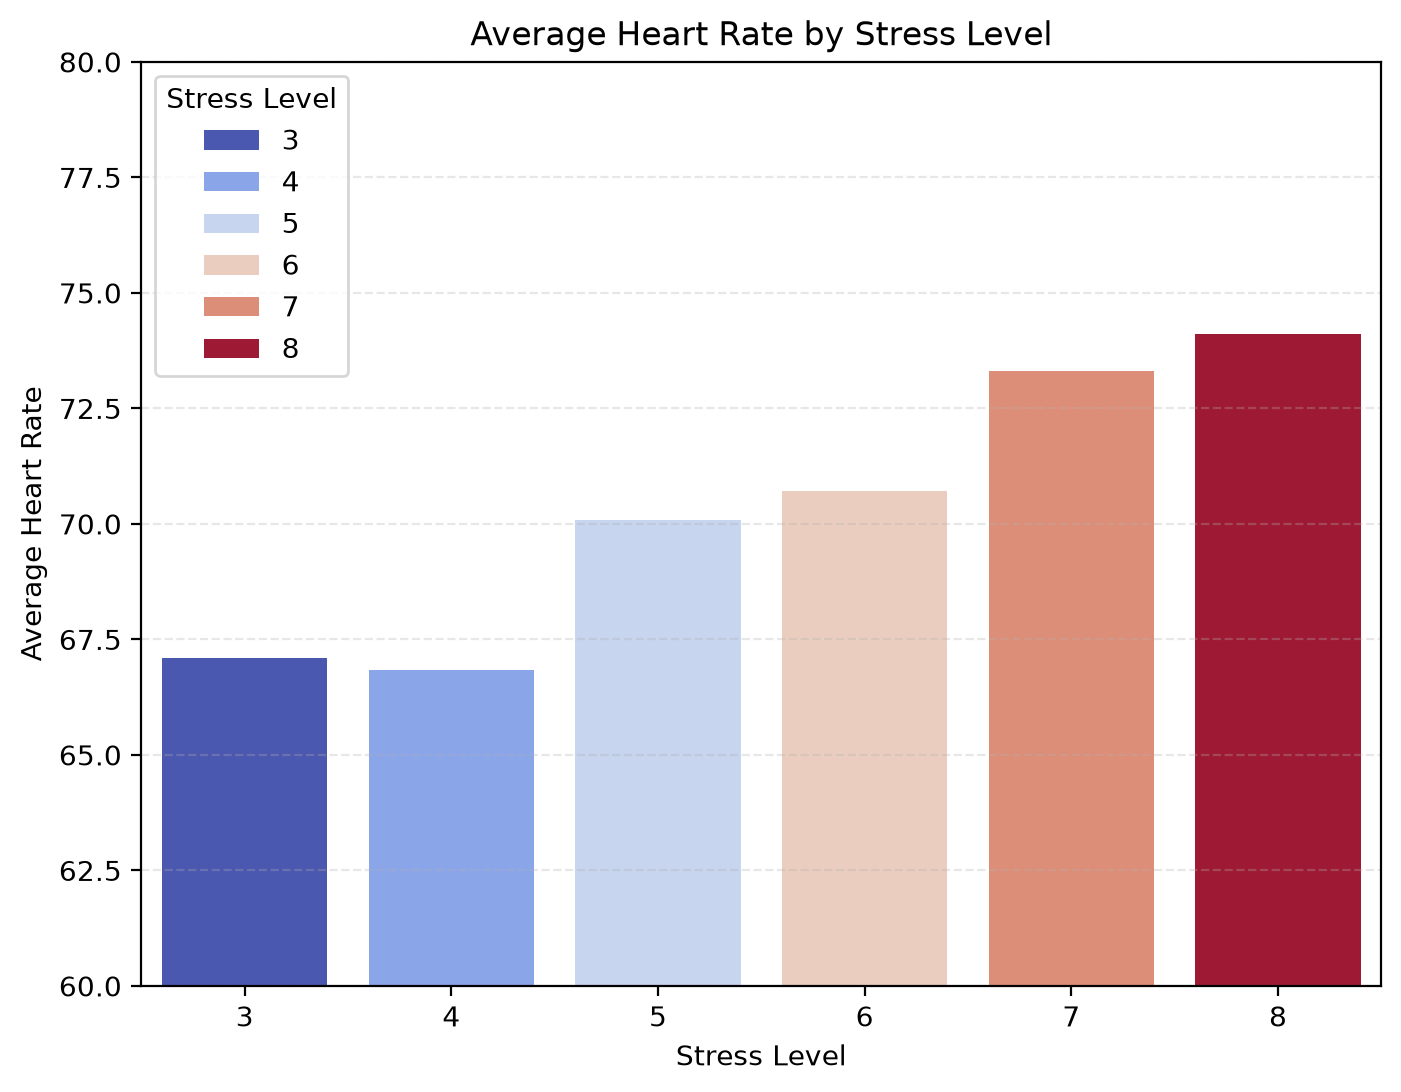

In [3]:
plt.figure(figsize=(8,6), dpi=200)
sns.barplot(data=df, x='Stress Level', y = 'Heart Rate', hue = 'Stress Level', palette = 'coolwarm', errorbar = None)
plt.ylim(60,80)
plt.ylabel('Average Heart Rate')
plt.title ('Average Heart Rate by Stress Level')
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

#### Key observations from the barplot:
- **Avg. heart rate and stress level:** We observe the mean heart rate increases with the stress level. Individuals with low stress levels (3-4) have a heart rate of about 67 bpm, at medium stress levels (5-6) the heart rate rises to 70 bpm, and at high stress levels (7-8) it rises up to 73 bpm.
- **Conclusion:**  These results partially support the first part of the Hypothesis #1. There is a physiological relationship - a high stress level positively correlates with a high heart rate. 

In [4]:
df[['Heart Rate', 'Sleep Duration', 'Quality of Sleep']].corr()

,Heart Rate,Sleep Duration,Quality of Sleep
Heart Rate,1.000000,-0.516455,-0.659865
Sleep Duration,-0.516455,1.000000,0.883213
Quality of Sleep,-0.659865,0.883213,1.000000


<Axes: xlabel='Sleep Duration', ylabel='Heart Rate'>

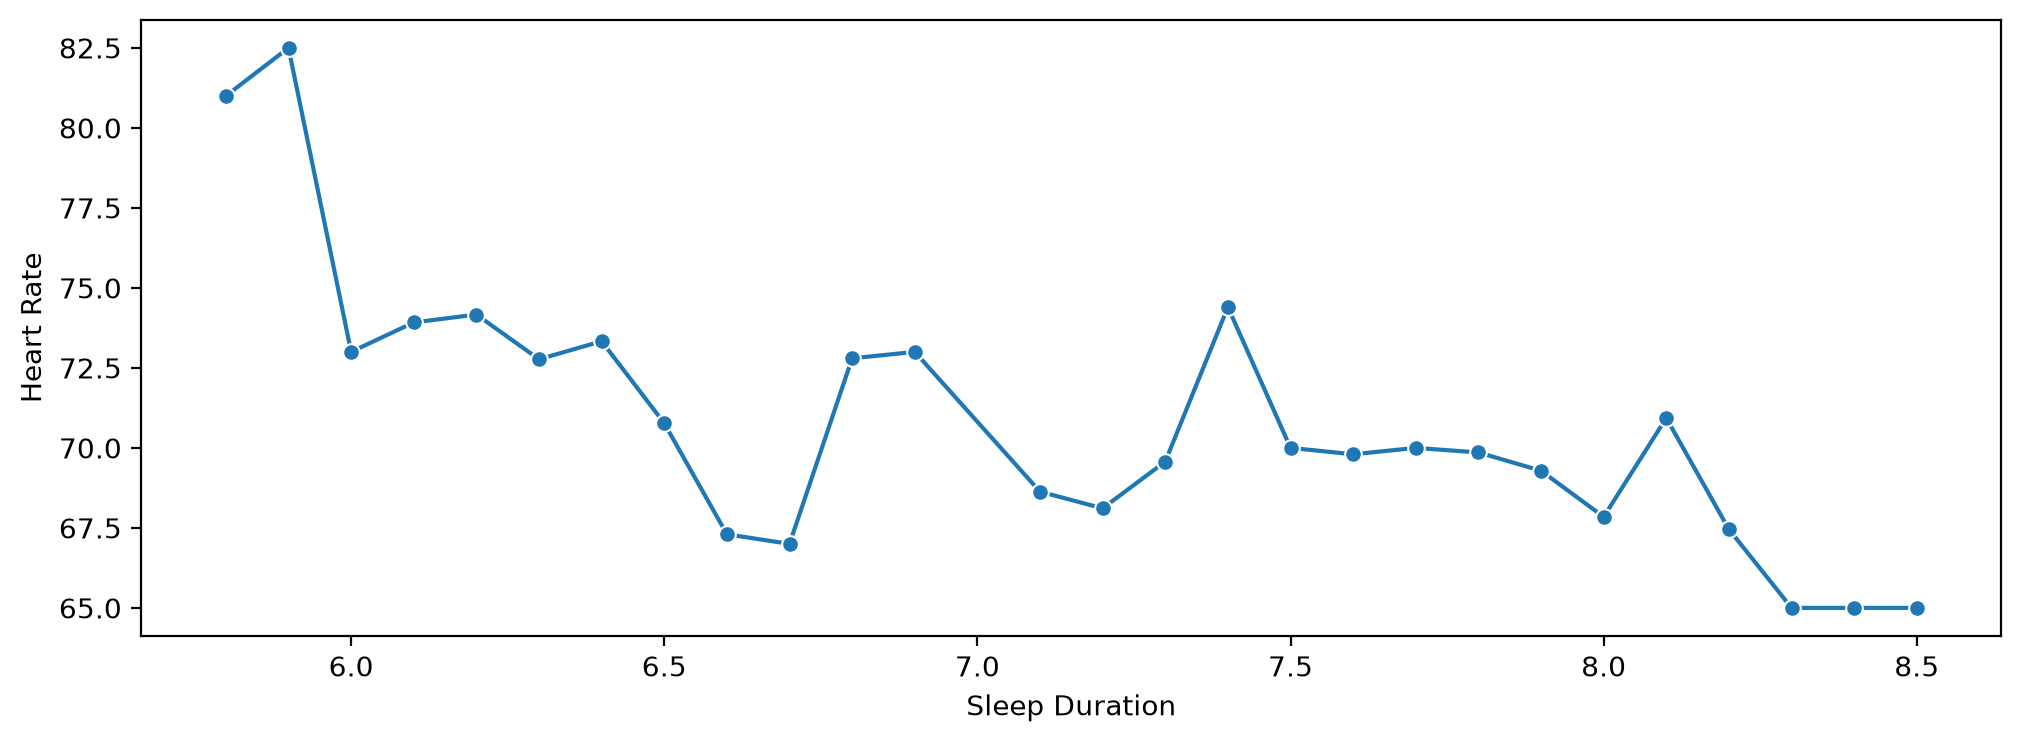

In [ ]:
plt.figure(figsize=(12,4), dpi=200)
sns.lineplot(data=df, x='Sleep Duration', y= 'Heart Rate',  marker='o', errorbar=None)

<Axes: xlabel='Quality of Sleep', ylabel='Heart Rate'>

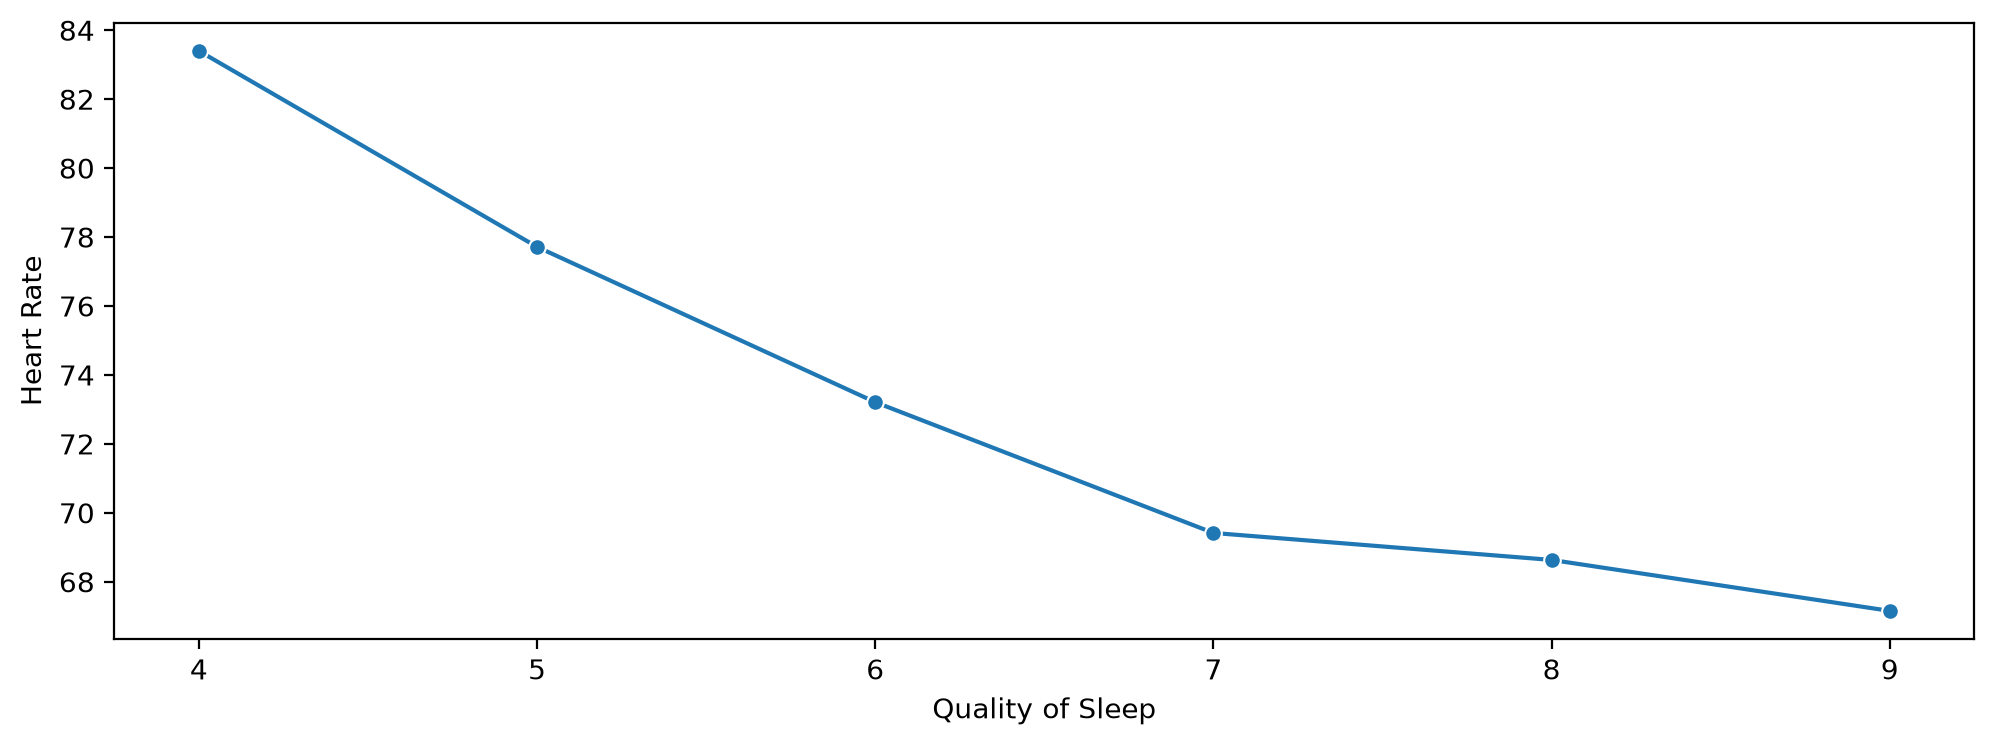

In [63]:
plt.figure(figsize=(12,4), dpi=200)
sns.lineplot(data=df, x='Quality of Sleep', y= 'Heart Rate', marker='o', errorbar=None)

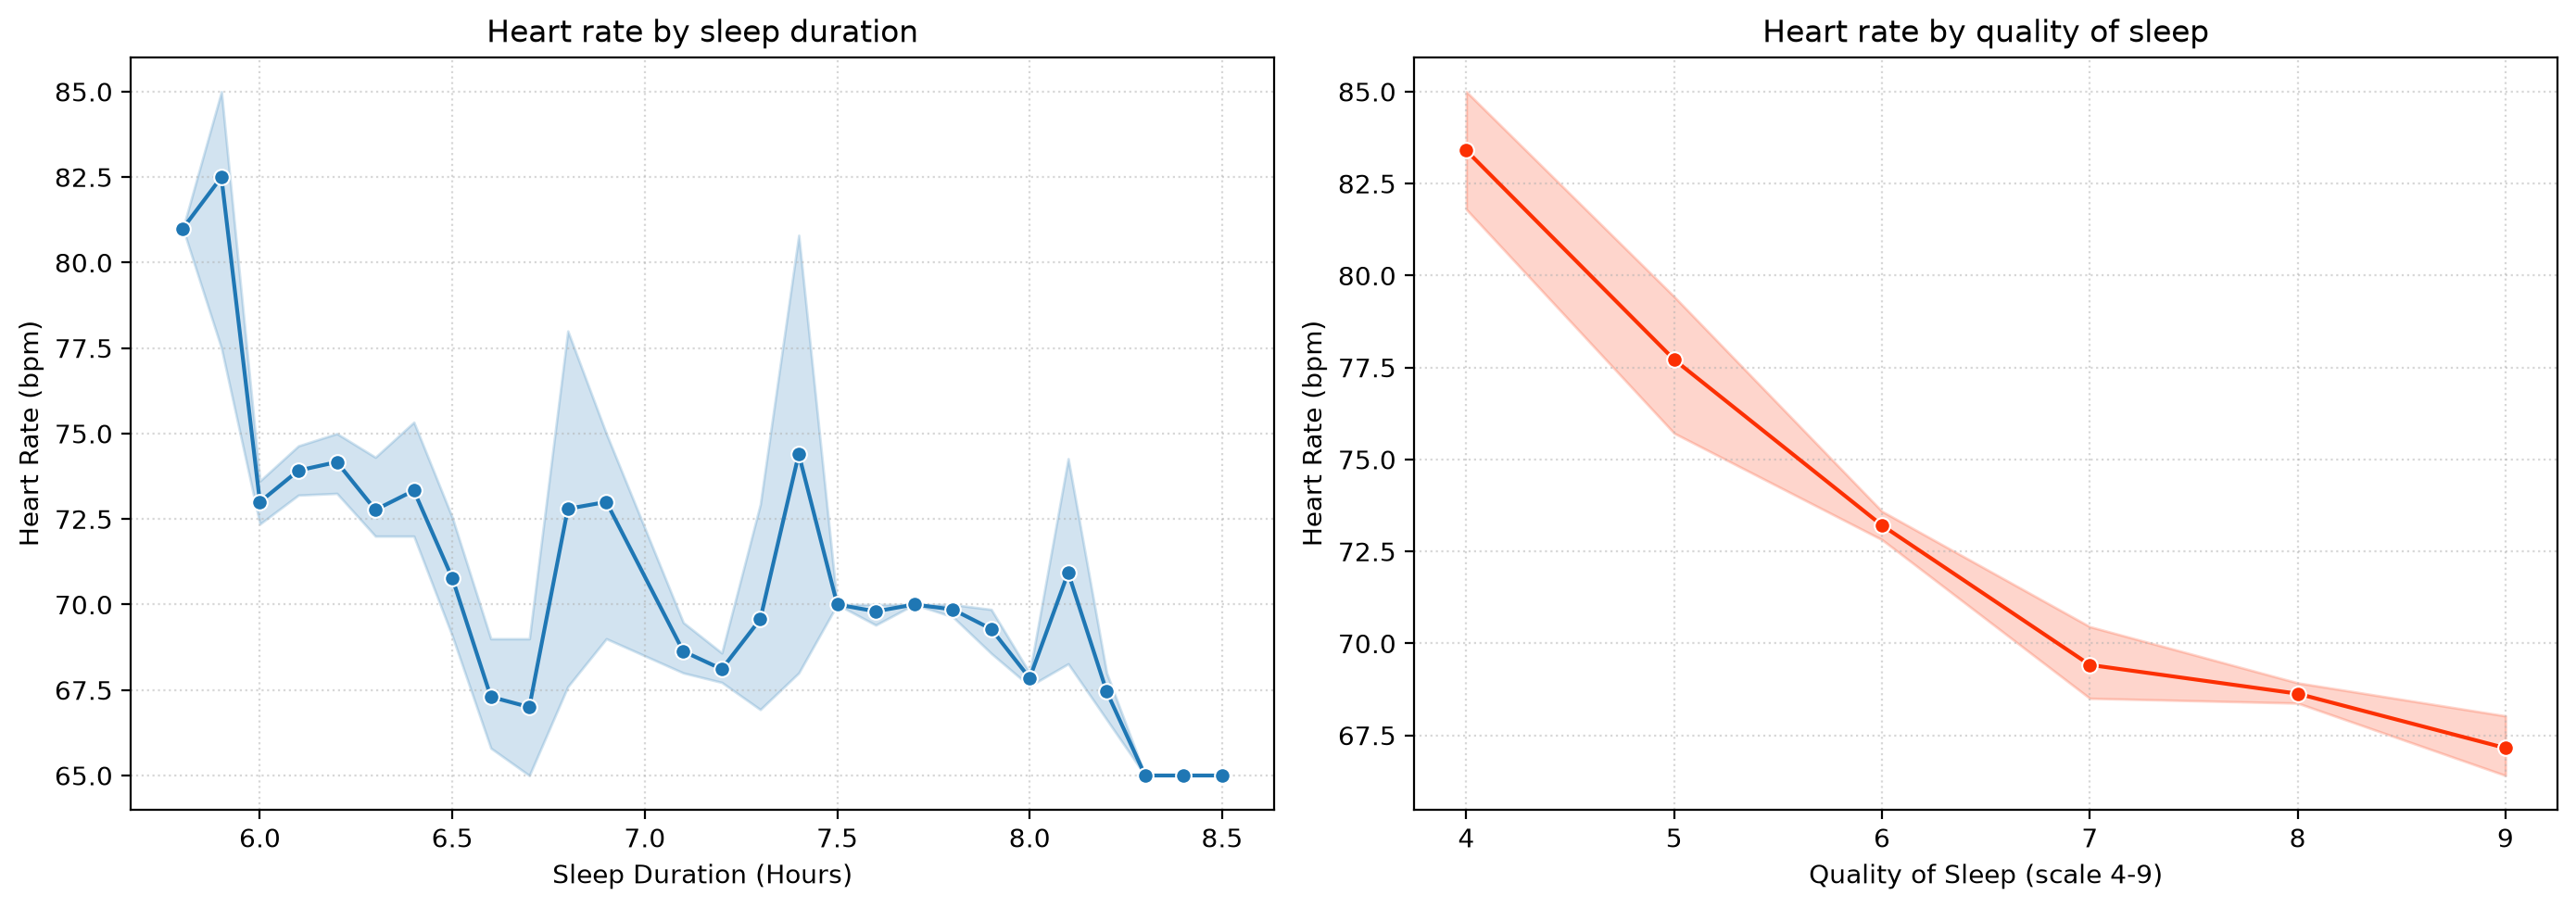

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=200)

# 1. Sleep duration vs Heart Rate
sns.lineplot(data=df, x='Sleep Duration', y= 'Heart Rate', marker='o', ax=axes[0])
axes[0].set_title('Heart rate by sleep duration')
axes[0].set_xlabel('Sleep Duration (Hours)')
axes[0].set_ylabel('Heart Rate (bpm)')
axes[0].grid(True, alpha = 0.5, linestyle = ':')

# 2. Sleep quality vs Heart Rate
sns.lineplot(data=df, x='Quality of Sleep', y= 'Heart Rate',marker='o', ax=axes[1], color = '#fc3003')
axes[1].set_title('Heart rate by quality of sleep')
axes[1].set_xlabel('Quality of Sleep (scale 4-9)')
axes[1].set_ylabel('Heart Rate (bpm)')
axes[1].grid(True, alpha = 0.5, linestyle = ':')

plt.tight_layout()

#### Key observations from the second step:

*   **Correlation with Sleep Quality:** There is a strong negative relationship between heart rate and sleep quality. Individuals with low sleep quality (rating 4) have a mean heart rate of **~83 bpm**, while those with high sleep quality (rating 8–9) have a much lower heart rate of **67–68 bpm**.
*   **Correlation with Sleep Duration:** Overall, longer sleep means a lower resting heart rate, dropping from **~81–83 bpm** (under 6 hours) down to **65 bpm** (8.5 hours). 
*   **Data Anomaly:** We can see two clear spikes in heart rate (up to **~75 bpm**) at **6.8–6.9** and **7.4 hours** of sleep, along with a wider confidence interval. This suggests other factors, like high stress levels in this group.
*   **Conclusion:** The results fully support Hypothesis #1. Poor sleep quality and short sleep duration are strong indicators of a higher resting heart rate.

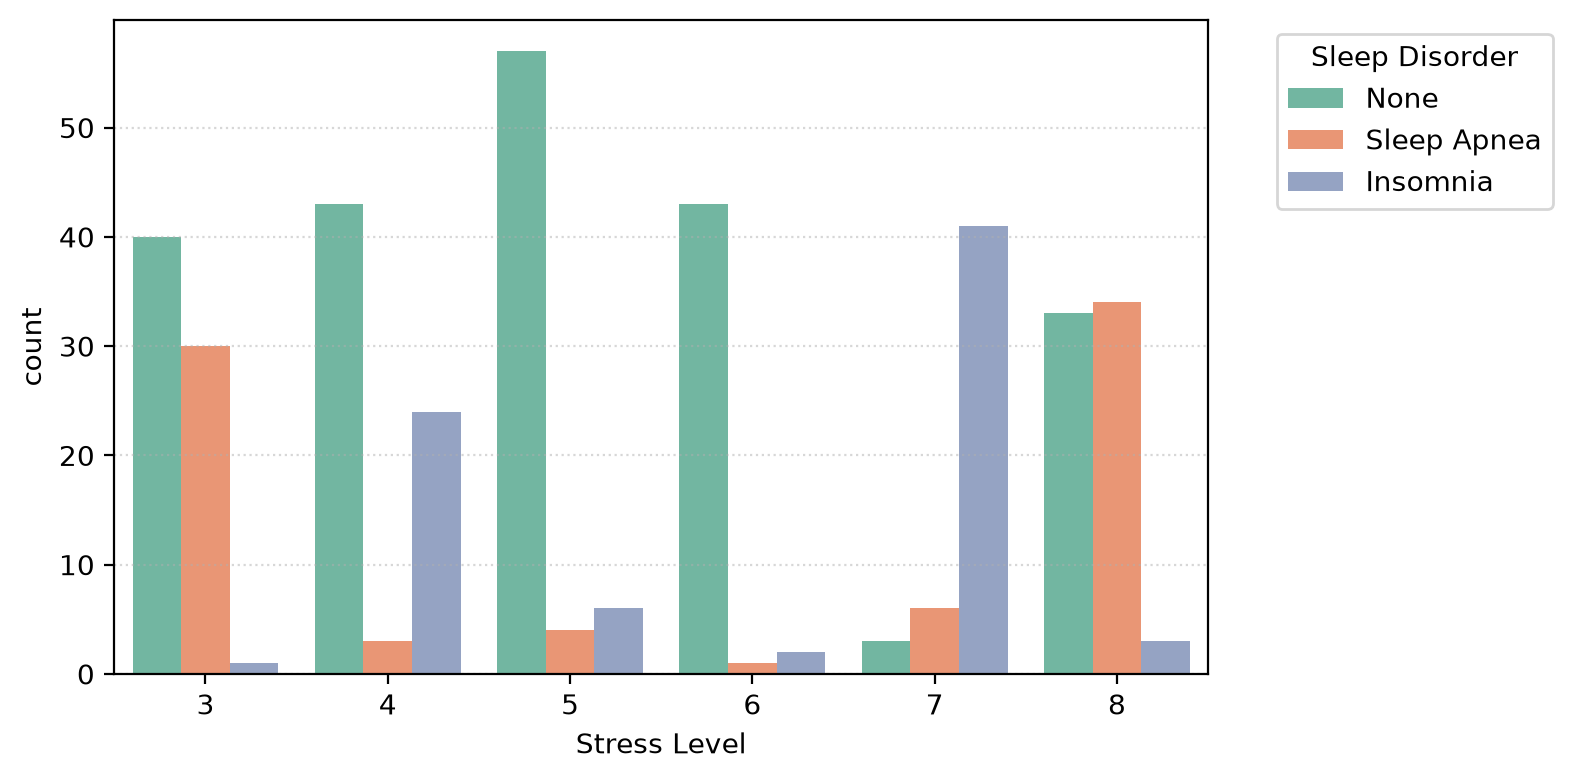

In [22]:
#We need to investigate the relationship between stress level and sleep disorder but we have NaN values for those who don't have any sleep disorder
#To correct that we need to transform our data.
df_without_nan = df.copy()
df_without_nan['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
plt.figure(figsize=(8,4), dpi=200)
sns.countplot(data=df_without_nan, x='Stress Level', hue='Sleep Disorder', palette='Set2')
plt.legend(title='Sleep Disorder', bbox_to_anchor=(1.05, 1), loc= 'upper left')
plt.grid(axis='y', linestyle = ':', alpha = 0.5 )
plt.tight_layout()

#### Key observations from the plot:

*   **Low to moderate stress (levels 3–6):** Most people in this group don't have any sleep disorders (`None`). However, there're spikes for `Sleep Apnea` at level 3 and `Insomnia` at level 4.
*   **High stress anomaly (level 7):** Individuals without sleep disorders are almost absent (less than 10 people). Instead, there is a massive peak in `Insomnia` (>40 cases), showing a strong link between high stress and insomnia but then at level 8 there are a few people with `Insomnia`, which looks like an anomaly.
*   **Extreme stress (level 8):** `Insomnia` drops sharply, while `Sleep Apnea` and healthy individuals (`None`) increase again, which suggests that factors other than stress (e.g., age or occupation) might influence this group.
*   **Conclusion:** There is no strong relationship between stress levels and sleep disorders. Instead, we observe the following: `Insomnia` is mainly concentrated at level 7 (high level) and appears at level 4 (low level), while `Sleep Apnea` appears at both low (level 3) and high (level 8) stress levels. 

Let's look at median values for other properties to see if we can notice a new pattern

In [38]:
columns_to_show = ['Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Heart Rate', 'Age']
df_without_nan.groupby(by='Sleep Disorder')[columns_to_show].describe().transpose()

Sleep Disorder           Insomnia        None  Sleep Apnea
Sleep Duration   count  77.000000  219.000000    78.000000
                 mean    6.589610    7.358447     7.032051
                 std     0.387157    0.732320     0.974812
                 min     5.900000    6.000000     5.800000
                 25%     6.400000    7.100000     6.100000
                 50%     6.500000    7.400000     6.800000
                 75%     6.600000    7.800000     8.100000
                 max     8.300000    8.500000     8.200000
Quality of Sleep count  77.000000  219.000000    78.000000
                 mean    6.532468    7.625571     7.205128
                 std     0.804337    0.975142     1.646397
                 min     4.000000    6.000000     4.000000
                 25%     6.000000    7.000000     6.000000
                 50%     7.000000    8.000000     6.000000
                 75%     7.000000    8.000000     9.000000
                 max     9.000000    9.000000     9.000000
Stress Level     count  77.000000  219.000000    78.000000
                 mean    5.870130    5.114155     5.666667
                 std     1.463150    1.591471     2.333643
                 min     3.000000    3.000000     3.000000
                 25%     4.000000    4.000000     3.000000
                 50%     7.000000    5.000000     7.000000
                 75%     7.000000    6.000000     8.000000
                 max     8.000000    8.000000     8.000000
Heart Rate       count  77.000000  219.000000    78.000000
                 mean   70.467532   69.018265    73.089744
                 std     4.948643    2.657797     5.117289
                 min    65.000000   65.000000    68.000000
                 25%    65.000000   68.000000    68.000000
                 50%    72.000000   70.000000    75.000000
                 75%    72.000000   70.000000    75.000000
                 max    85.000000   77.000000    86.000000
Age              count  77.000000  219.000000    78.000000
                 mean   43.519481   39.036530    49.705128
                 std     4.808464    7.827764     8.990773
                 min    28.000000   27.000000    28.000000
                 25%    43.000000   32.000000    49.000000
                 50%    44.000000   38.000000    50.000000
                 75%    45.000000   43.000000    57.750000
                 max    53.000000   59.000000    59.000000

In [37]:
columns_to_show = ['Sleep Duration', 'Quality of Sleep', 'Heart Rate', 'Age']
df_without_nan.groupby(by=['Sleep Disorder','Gender'])[columns_to_show].describe().transpose()

Sleep Disorder           Insomnia                  None              \
Gender                     Female       Male     Female        Male   
Sleep Duration   count  36.000000  41.000000  82.000000  137.000000   
                 mean    6.633333   6.551220   7.650000    7.183942   
                 std     0.326015   0.434236   0.730001    0.678475   
                 min     6.100000   5.900000   6.000000    6.000000   
                 25%     6.500000   6.300000   7.100000    6.700000   
                 50%     6.600000   6.400000   7.200000    7.400000   
                 75%     6.600000   6.500000   8.400000    7.700000   
                 max     8.300000   7.800000   8.500000    7.900000   
Quality of Sleep count  36.000000  41.000000  82.000000  137.000000   
                 mean    6.944444   6.170732   8.280488    7.233577   
                 std     0.629941   0.771441   0.835544    0.833691   
                 min     5.000000   4.000000   6.000000    6.000000   
                 25%     7.000000   6.000000   8.000000    6.000000   
                 50%     7.000000   6.000000   8.000000    7.000000   
                 75%     7.000000   6.000000   9.000000    8.000000   
                 max     9.000000   8.000000   9.000000    8.000000   
Heart Rate       count  36.000000  41.000000  82.000000  137.000000   
                 mean   67.305556  73.243902  67.548780   69.897810   
                 std     4.159804   3.806445   3.095805    1.879787   
                 min    65.000000  68.000000  65.000000   65.000000   
                 25%    65.000000  72.000000  65.000000   68.000000   
                 50%    65.000000  72.000000  68.000000   70.000000   
                 75%    69.000000  72.000000  68.000000   70.000000   
                 max    80.000000  85.000000  77.000000   77.000000   
Age              count  36.000000  41.000000  82.000000  137.000000   
                 mean   44.944444  42.268293  44.926829   35.510949   
                 std     5.258704   4.037477   8.242888    4.930572   
                 min    29.000000  28.000000  31.000000   27.000000   
                 25%    44.000000  43.000000  37.000000   31.000000   
                 50%    45.000000  43.000000  45.000000   35.000000   
                 75%    45.000000  44.000000  53.000000   40.000000   
                 max    53.000000  48.000000  59.000000   44.000000   

Sleep Disorder         Sleep Apnea             
Gender                      Female       Male  
Sleep Duration   count   67.000000  11.000000  
                 mean     7.035821   7.009091  
                 std      0.997072   0.868855  
                 min      5.800000   5.900000  
                 25%      6.100000   6.250000  
                 50%      6.800000   7.100000  
                 75%      8.100000   7.750000  
                 max      8.200000   8.100000  
Quality of Sleep count   67.000000  11.000000  
                 mean     7.298507   6.636364  
                 std      1.614470   1.804036  
                 min      4.000000   4.000000  
                 25%      6.000000   5.500000  
                 50%      6.000000   7.000000  
                 75%      9.000000   8.000000  
                 max      9.000000   9.000000  
Heart Rate       count   67.000000  11.000000  
                 mean    72.402985  77.272727  
                 std      4.249990   7.747140  
                 min     68.000000  68.000000  
                 25%     68.000000  70.000000  
                 50%     75.000000  74.000000  
                 75%     75.000000  85.000000  
                 max     84.000000  86.000000  
Age              count   67.000000  11.000000  
                 mean    51.761194  37.181818  
                 std      7.373354   7.922350  
                 min     29.000000  28.000000  
                 25%     49.500000  30.000000  
                 50%     50.000000  36.000000  
                 75%     58.000000  43.000000  
 